In [1]:
import kagglehub
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# 1. تحميل الداتا سيت
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Dataset Path:", path)

# 2. تحديد المسار الصحيح للصور الملونة
dataset_dir = os.path.join(path, 'plantvillage dataset', 'color')

# 3. إعدادات الصور
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# 4. تقسيم البيانات (80% تدريب - 20% اختبار)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES}")

# 5. إعداد طبقة الـ Data Augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset Path: /kaggle/input/plantvillage-dataset
Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Number of classes: 38


--- Starting Approach 1: SVM with DL Features ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting features (This might take a moment)...
Training SVM...

Approach 1 Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98       120
                                 Apple___Black_rot       1.00      1.00      1.00       124
                          Apple___Cedar_apple_rust       1.00      0.98      0.99        56
                                   Apple___healthy       0.99      0.99      0.99       348
                               Blueberry___healthy       1.00      1.00      1.00       318
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       208
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.8

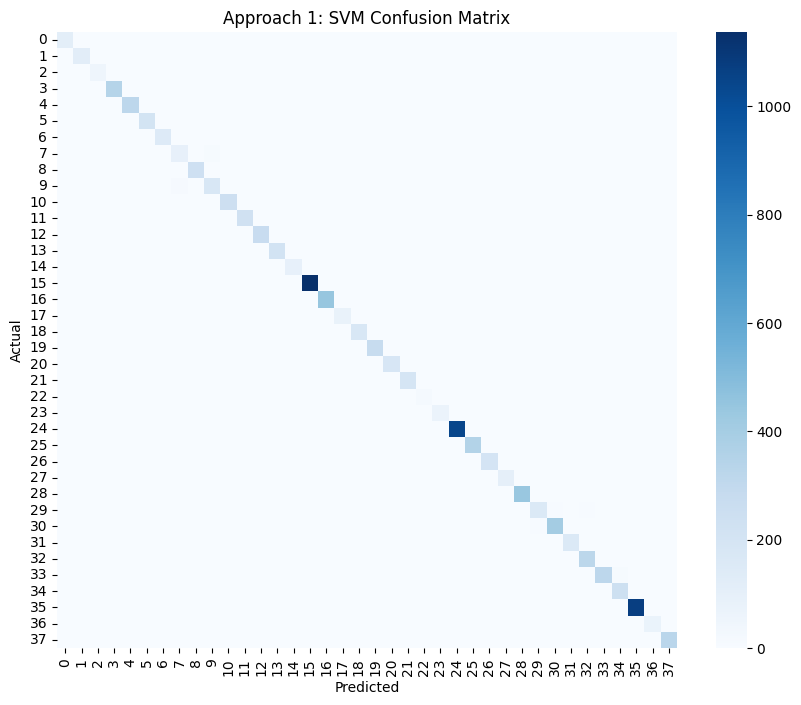

In [2]:
print("--- Starting Approach 1: SVM with DL Features ---")

# 1. تحميل الموديل كمستخرج ميزات
feature_extractor = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

# 2. دالة استخراج الميزات
def extract_features(dataset):
    features, labels = [], []
    for images, batch_labels in dataset:
        # استخدام المعالجة المسبقة الخاصة بـ EfficientNet
        preprocessed_images = preprocess_input(images)
        preds = feature_extractor.predict(preprocessed_images, verbose=0)
        features.append(preds)
        labels.append(batch_labels.numpy())
    return np.vstack(features), np.concatenate(labels)

print("Extracting features (This might take a moment)...")
X_train, y_train = extract_features(train_dataset)
X_val, y_val = extract_features(validation_dataset)

# 3. تدريب الـ SVM
print("Training SVM...")
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# 4. التقييم
svm_preds = svm_model.predict(X_val)
print("\nApproach 1 Classification Report:\n")
print(classification_report(y_val, svm_preds, target_names=class_names))

# 5. رسم مصفوفة الارتباك
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, svm_preds), annot=False, cmap="Blues")
plt.title("Approach 1: SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

--- Starting Approach 2: End-to-End Deep Learning ---
Training Model...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 543s 370ms/step - accuracy: 0.8793 - loss: 0.4843 - val_accuracy: 0.9810 - val_loss: 0.0629
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 555s 367ms/step - accuracy: 0.9811 - loss: 0.0649 - val_accuracy: 0.9758 - val_loss: 0.0800
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 496s 365ms/step - accuracy: 0.9887 - loss: 0.0378 - val_accuracy: 0.9914 - val_loss: 0.0277
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 497s 366ms/step - accuracy: 0.9909 - loss: 0.0296 - val_accuracy: 0.9921 - val_loss: 0.0259
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 497s 366ms/step - accuracy: 0.9928 - loss: 0.0234 - val_accuracy: 0.9864 - val_loss: 0.0474
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 497s 366ms/step - accuracy: 0.9939 - loss: 0.0193 - val_accuracy: 0.9937 - val_loss: 0.0207
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 497s 366ms/step - accuracy: 0.9950 - loss: 0.0155 - val_accuracy: 0.9924 - val_los

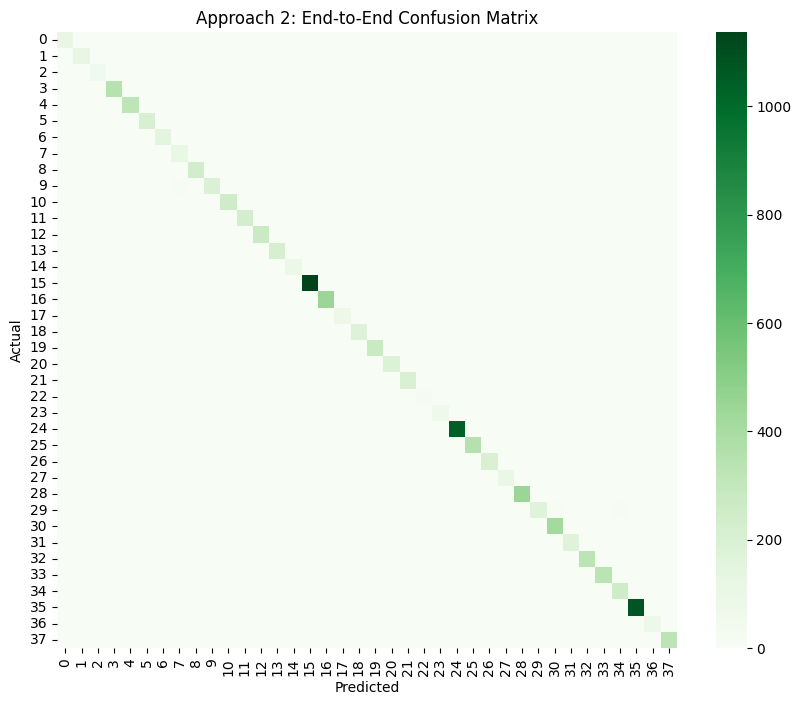

In [3]:
print("--- Starting Approach 2: End-to-End Deep Learning ---")

# 1. بناء النموذج المتكامل
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x) # مهمة جداً لـ EfficientNet بدلاً من 1/255

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
base_model.trainable = True # السماح بالتدريب End-to-End

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

end_to_end_model = tf.keras.Model(inputs, outputs)

# 2. تجميع النموذج
end_to_end_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. التدريب
print("Training Model...")
history = end_to_end_model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)

# 4. التقييم الثابت (عشان الـ Confusion Matrix تطلع مظبوطة)
print("\nEvaluating End-to-End Model...")
y_true_e2e = []
e2e_pred_classes = []

for images, labels in validation_dataset:
    preds = end_to_end_model.predict(images, verbose=0)
    e2e_pred_classes.extend(np.argmax(preds, axis=1))
    y_true_e2e.extend(labels.numpy())

print("\nApproach 2 Classification Report:\n")
print(classification_report(y_true_e2e, e2e_pred_classes, target_names=class_names))

# 5. رسم مصفوفة الارتباك
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true_e2e, e2e_pred_classes), annot=False, cmap="Greens")
plt.title("Approach 2: End-to-End Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

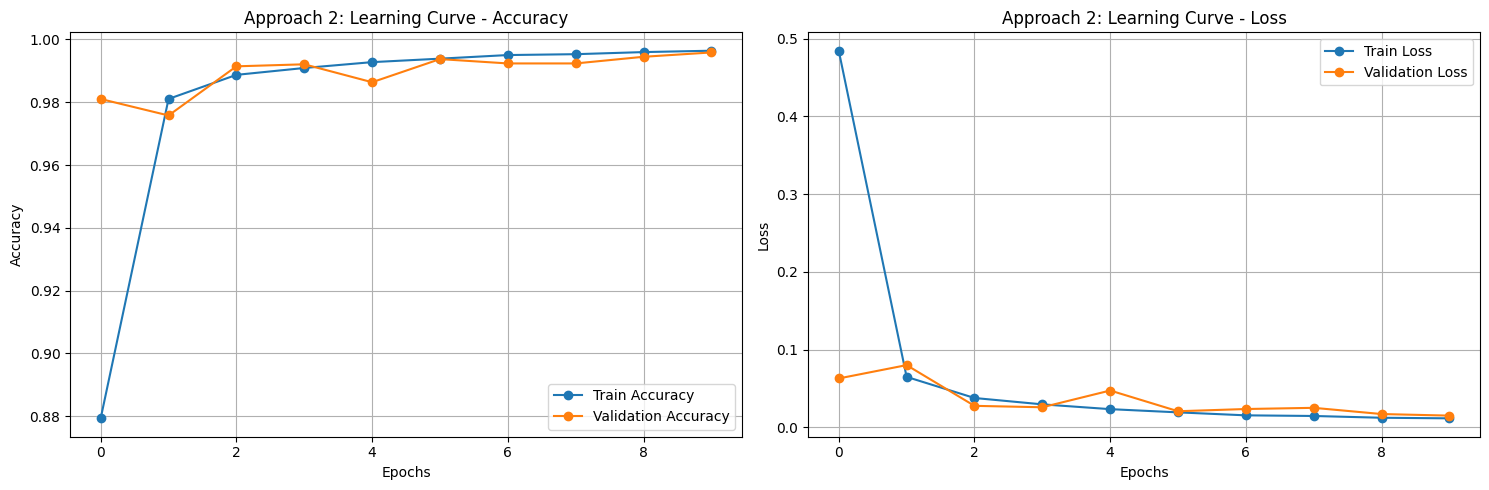

In [4]:
# رسم منحنيات الدقة والخسارة لنموذج الـ End-to-End
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# الدقة (Accuracy)
axs[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axs[0].set_title('Approach 2: Learning Curve - Accuracy')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy')
axs[0].legend()
axs[0].grid(True)

# الخسارة (Loss)
axs[1].plot(history.history['loss'], label='Train Loss', marker='o')
axs[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axs[1].set_title('Approach 2: Learning Curve - Loss')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()